# Matplotlib

- <https://matplotlib.org>;
- o pyplot é um modulo do matplotlib que possui graficos básicos normalmente usados nessa biblioteca

In [2]:
import matplotlib.pyplot as plt
import numpy as np

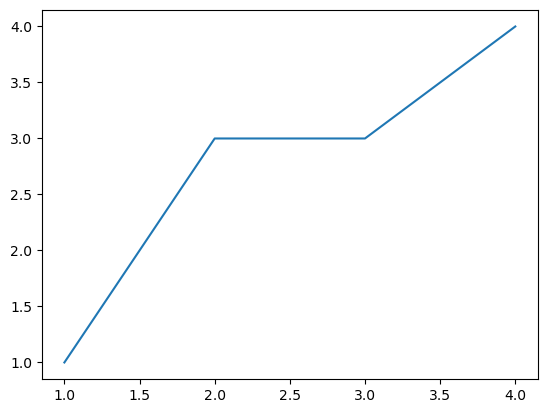

In [3]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.
ax.plot([1, 2, 3, 4], [1, 3, 3, 4])  # Plot some data on the Axes.
plt.show()                           # Show the figure.

<Figure size 640x480 with 0 Axes>

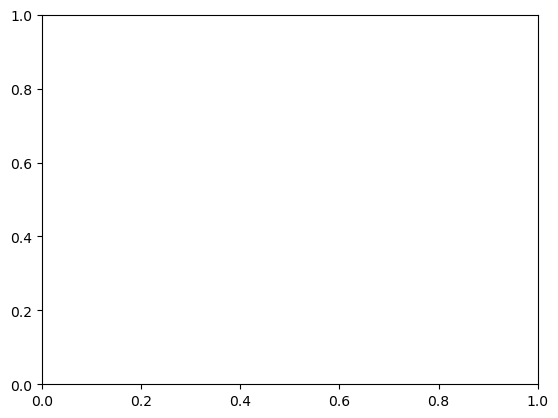

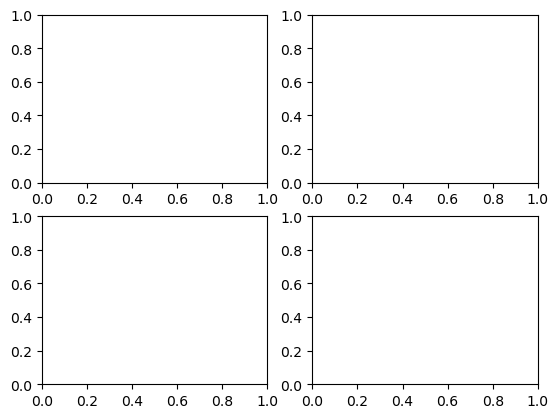

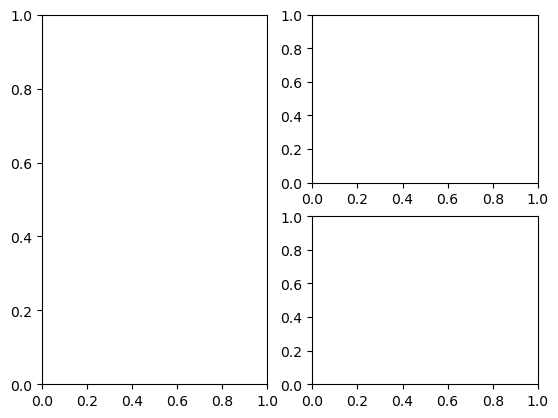

In [4]:
fig = plt.figure()             # an empty figure with no Axes
fig, ax = plt.subplots()       # a figure with a single Axes
fig, axs = plt.subplots(2, 2)  # a figure with a 2x2 grid of Axes
# a figure with one Axes on the left, and two on the right:
fig, axs = plt.subplot_mosaic([['left', 'right_top'],['left', 'right_bottom']])

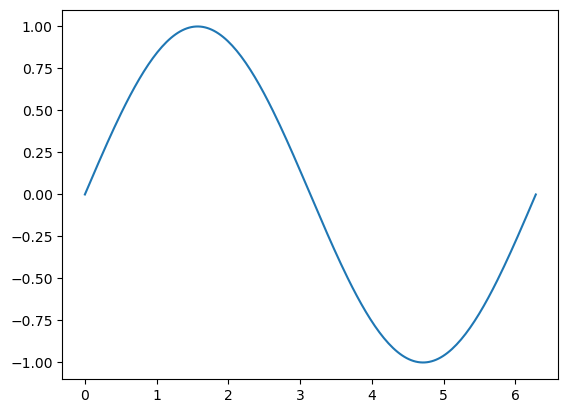

In [5]:
x = np.linspace(0, 2 * np.pi, 200)
y = np.sin(x)

fig, ax = plt.subplots()
ax.plot(x, y)
plt.show()

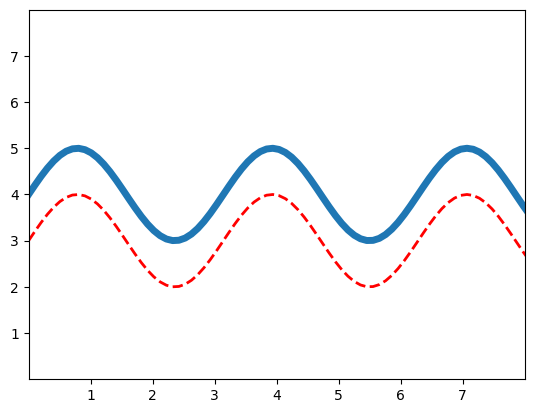

In [6]:
x92 = np.linspace(0, 10, 100)
y92 = 4 + np.sin(2*x92)

#plot

x921 = np.linspace(0, 10, 100)
y921 = 3 + np.sin(2*x92)


fig, ax = plt.subplots()
ax.plot(x92, y92, linewidth=5)
ax.plot(x921, y921,'r--', linewidth=2)

ax.set(xlim=(0,8), xticks=np.arange(1,8),
       ylim=(0,8), yticks=np.arange(1,8)
       )
plt.show()

In [7]:
import pandas as pd

base = pd.read_excel('dados-instagram.xlsx')
base = base.drop('Visualizações', axis=1)
base.loc[base['Carrossel'].isnull(), 'Carrossel'] = "N"

In [8]:
base.head()

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
0,Foto,2021-09-11,2858,16,Loja,N,N,N,2874
1,Foto,2021-09-11,2930,28,Loja/Produtos,N,N,N,2958
2,Foto,2021-09-11,2807,9,Loja,N,N,N,2816
3,Vídeo,2021-09-12,5115,49,Produtos,N,N,N,5164
4,Foto,2021-09-13,4392,45,Produtos,S,N,N,4437


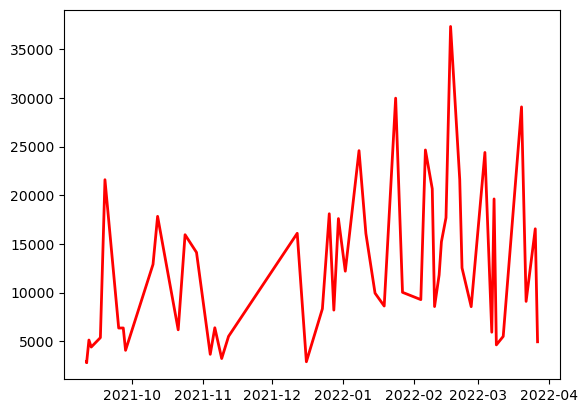

In [9]:
x92Data = base.Data
y92Curtidas = base.Curtidas
y92Coments = base.Comentários


#plot

fig, ax = plt.subplots()

ax.plot(x92Data, y92Curtidas, linewidth=2, c='red')
# ax.scatter(x92Data, y92Curtidas, linewidth=2)
# ax.bar(x92Data, y92Curtidas, width=5, edgecolor='white')

plt.show()

# #094 (Opcional) Entendendo a documentação do Matplotlib

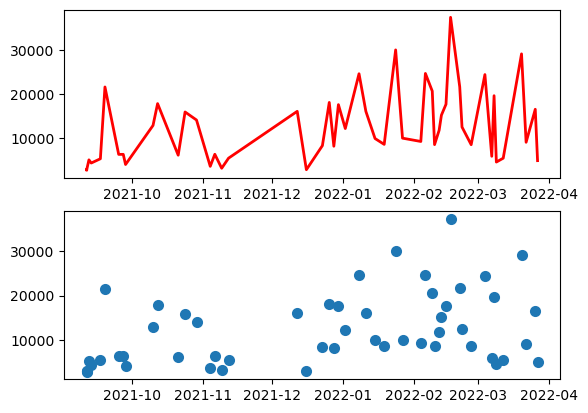

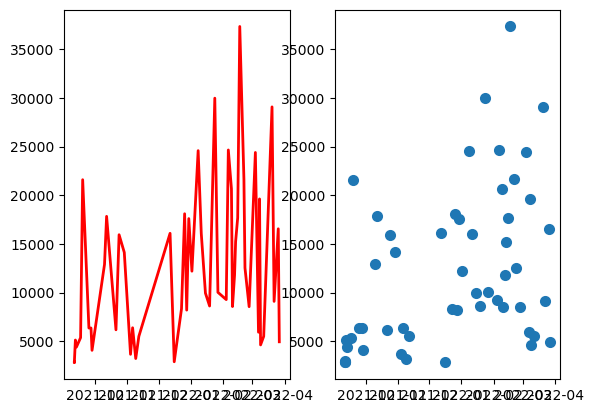

In [10]:
x94Data = base.Data
y94Curtidas = base.Curtidas
y94Coments = base.Comentários


#plot

fig, ax = plt.subplots(nrows=2, ncols=1)

ax[0].plot(x94Data, y94Curtidas, linewidth=2, c='red')
ax[1].scatter(x94Data, y94Curtidas, linewidth=2)
# ax.bar(x92Data, y92Curtidas, width=5, edgecolor='white')

fig2, ax2 = plt.subplots(nrows=1, ncols=2)

ax2[0].plot(x94Data, y94Curtidas, linewidth=2, c='red')
ax2[1].scatter(x94Data, y94Curtidas, linewidth=2)

plt.show()

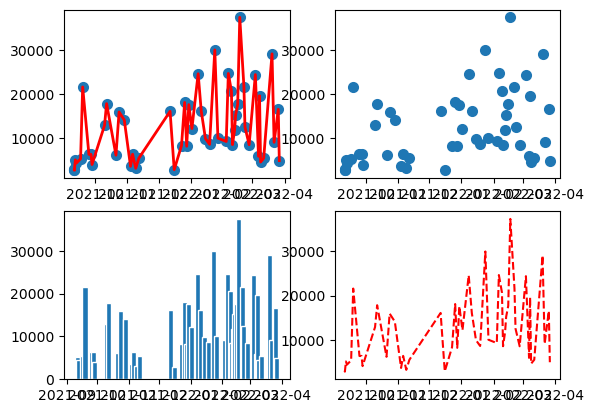

In [11]:


#plot

fig, ax = plt.subplots(nrows=2, ncols=2)

ax[0][0].plot(x94Data, y94Curtidas, linewidth=2, c='red')
ax[0][0].scatter(x94Data, y94Curtidas, linewidth=2)

ax[0][1].scatter(x94Data, y94Curtidas, linewidth=2)
ax[1][0].bar(x94Data, y94Curtidas, width=5, edgecolor='white')
ax[1][1].plot(x94Data, y94Curtidas, 'r--')


plt.show()

# #095 Usando gráficos (de linha) para entender os dados (máximo, mínimo e média mensal de curtidas)

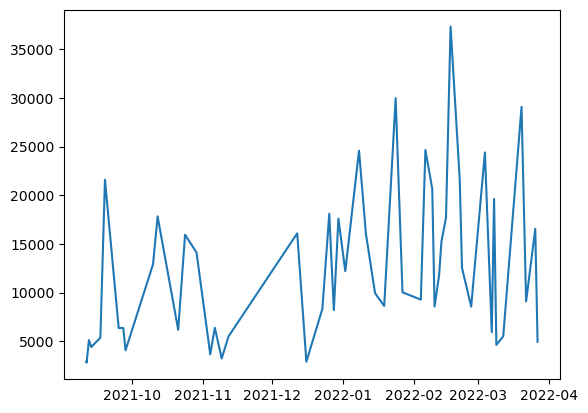

In [16]:
x95Data = base.Data
y95Curtidas = base.Curtidas
y95Coments = base.Comentários

fig, ax = plt.subplots()

ax.plot(x95Data, y95Curtidas)

plt.show();

## Será que existe uma tendencia de que nas curtidas

- vamos fazer uma nalise mensal
    - para isso precisamos criar a coluna mês/ano

In [ ]:
# Criando a coluna do mês
import datetime as dt
base["mes"] = base.Data.dt.year*100  + base.Data.dt.month
## dt.isocalendar()
print(base.Data.head().dt.year*100)
# VErificando a coluna criada

base.head()

0    202100
1    202100
2    202100
3    202100
4    202100
Name: Data, dtype: int64


,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes,mes
0,Foto,2021-09-11,2858,16,Loja,N,N,N,2874,202109
1,Foto,2021-09-11,2930,28,Loja/Produtos,N,N,N,2958,202109
2,Foto,2021-09-11,2807,9,Loja,N,N,N,2816,202109
3,Vídeo,2021-09-12,5115,49,Produtos,N,N,N,5164,202109
4,Foto,2021-09-13,4392,45,Produtos,S,N,N,4437,202109


In [ ]:
## Semana
base.Data.dt.isocalendar()

,year,week,day
0,2021,36,6
1,2021,36,6
2,2021,36,6
3,2021,36,7
4,2021,37,1
5,2021,37,5
6,2021,37,7
7,2021,38,6
8,2021,39,1
9,2021,39,2


In [26]:
## Relembrando o groupby
media_mensal = base.groupby("mes")["Curtidas"].mean()
print(media_mensal)

mes
202109     6181.500000
202110    13390.400000
202111     4682.000000
202112    11863.833333
202201    15913.285714
202202    17081.363636
202203    13299.555556
Name: Curtidas, dtype: float64


In [27]:
# O group by vai ter o index

media_mensal.index

Int64Index([202109, 202110, 202111, 202112, 202201, 202202, 202203], dtype='int64', name='mes')

In [28]:
# O group by vai ter os valores

media_mensal.values

array([ 6181.5       , 13390.4       ,  4682.        , 11863.83333333,
       15913.28571429, 17081.36363636, 13299.55555556])

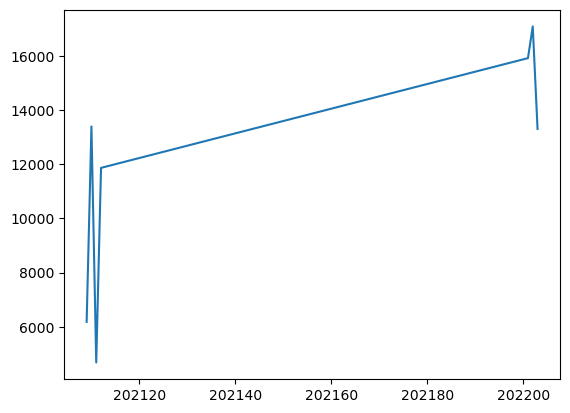

In [34]:
# Podemos usar exatamente essas informações para criar o nosso grafico

x = media_mensal.index
y = media_mensal.values
fig, ax = plt.subplots()
ax.plot(x, y)

plt.show()


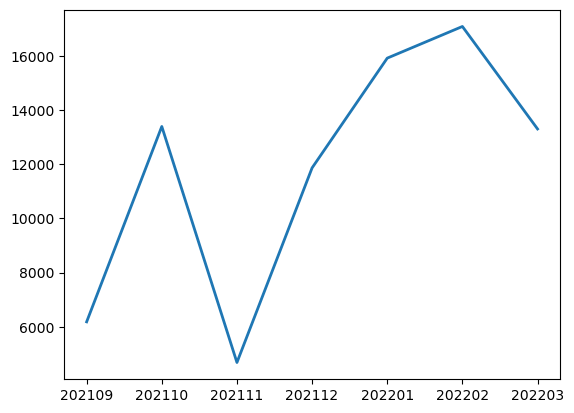

In [37]:
# Podemos usar exatamente essas informações para criar o nosso grafico

x = media_mensal.index.astype(str)
y = media_mensal.values
fig, ax = plt.subplots()
ax.plot(x, y, linewidth=2)

plt.show()


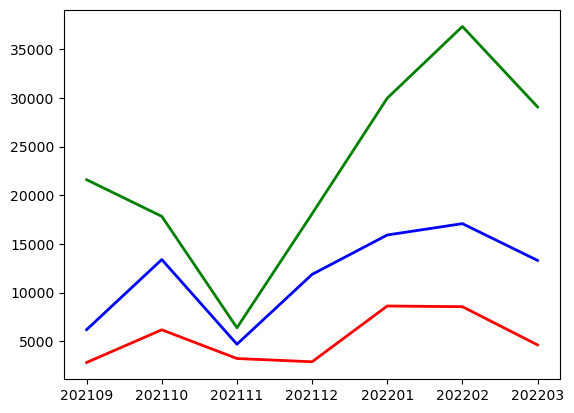

In [43]:
# Adicionando novos dados nesse grafico
# Verificando se o grafico não teve interferencia de outliers

minimo = base.groupby("mes")["Curtidas"].min()
maximo = base.groupby("mes")["Curtidas"].max()

# make data


x = media_mensal.index.astype(str)
y = media_mensal.values
x1 = minimo.index.astype(str)
y1 = minimo.values
x2 = maximo.index.astype(str)
y2 = maximo.values

fig, ax = plt.subplots()
ax.plot(x, y, linewidth=2, c='b')
ax.plot(x1, y1, linewidth=2, c='r')
ax.plot(x2, y2, linewidth=2, c='g')


plt.show()

In [45]:
# Entendendo os dados dos ultimos 2 meses
# VErificar se as promoções estão influenciando nas curtidas
base[(base.mes >= 202202)].sort_values(["mes","Curtidas"], ascending=False)

## Graficos ajudam a apresentar e interpretar melhor os dados

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes,mes
48,Foto,2022-03-20,29084,479,Datas comemorativas/Promoções,S,S,N,29563,202203
43,Foto,2022-03-04,24399,266,NaN,S,S,N,24665,202203
45,Reels,2022-03-08,19621,275,Trends,S,S,N,19896,202203
50,Foto,2022-03-26,16551,186,NaN,S,N,N,16737,202203
49,Foto,2022-03-22,9087,106,NaN,S,S,N,9193,202203
44,IGTV,2022-03-07,5918,116,Dicas de como usar/Novos Produtos,S,N,N,6034,202203
47,IGTV,2022-03-12,5489,77,Dicas de como usar/Novos Produtos,S,N,N,5566,202203
51,IGTV,2022-03-27,4934,65,Dicas de como usar/Produtos,S,N,N,4999,202203
46,Foto,2022-03-09,4613,50,Influenciadores,S,N,N,4663,202203
39,Foto,2022-02-17,37351,502,Promoções,S,S,N,37853,202202


# 096 

### Aconteceu um post patrocinado que aumentou muito as vendas de fevereiro
### Foi a unica vez que tivemos post patrocinado ? Vamos buscar isso nas tags
- Podemos usar o contains para procurar a palavra patrocinado nas tags
- porem o contains não aceita se tiver valores NaN, então precisamo tratar isso antes

In [54]:
# Tentando usar o contains sem trar os valores NaN

base[base.Tags.str.contains("Promoções")]


ValueError: Cannot mask with non-boolean array containing NA / NaN values

In [55]:
## Uma forma de fazer
base[(base.Tags.str.contains("Promoções")) & (base.Tags.isnull() == False)]




,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes,mes
13,Foto,2021-10-24,15940,612,Promoções,S,N,N,16552,202110
39,Foto,2022-02-17,37351,502,Promoções,S,S,N,37853,202202
48,Foto,2022-03-20,29084,479,Datas comemorativas/Promoções,S,S,N,29563,202203


In [62]:
# Forma do curso usandoi o fillna() ->  vai substituir os valores NaN pelo novo valor que passarmos
display(base.tail())
base.fillna("").tail()


,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes,mes
47,IGTV,2022-03-12,5489,77,Dicas de como usar/Novos Produtos,S,N,N,5566,202203
48,Foto,2022-03-20,29084,479,Datas comemorativas/Promoções,S,S,N,29563,202203
49,Foto,2022-03-22,9087,106,NaN,S,S,N,9193,202203
50,Foto,2022-03-26,16551,186,NaN,S,N,N,16737,202203
51,IGTV,2022-03-27,4934,65,Dicas de como usar/Produtos,S,N,N,4999,202203


,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes,mes
47,IGTV,2022-03-12,5489,77,Dicas de como usar/Novos Produtos,S,N,N,5566,202203
48,Foto,2022-03-20,29084,479,Datas comemorativas/Promoções,S,S,N,29563,202203
49,Foto,2022-03-22,9087,106,,S,S,N,9193,202203
50,Foto,2022-03-26,16551,186,,S,N,N,16737,202203
51,IGTV,2022-03-27,4934,65,Dicas de como usar/Produtos,S,N,N,4999,202203


In [70]:
base[base.fillna("").Tags.str.contains("Promoções")]


,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes,mes


In [ ]:
# base = base.drop(base[base.fillna("").Tags.str.contains("Promoções")].index, axis=0);

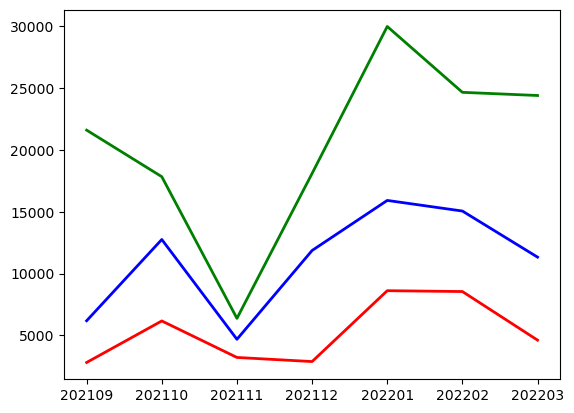

In [73]:
# Adicionando novos dados nesse grafico
# Verificando se o grafico não teve interferencia de outliers

media_mensal = base.groupby("mes")["Curtidas"].mean()
minimo = base.groupby("mes")["Curtidas"].min()
maximo = base.groupby("mes")["Curtidas"].max()

# make data


x = media_mensal.index.astype(str)
y = media_mensal.values
x1 = minimo.index.astype(str)
y1 = minimo.values
x2 = maximo.index.astype(str)
y2 = maximo.values

fig, ax = plt.subplots()
ax.plot(x, y, linewidth=2, c='b')
ax.plot(x1, y1, linewidth=2, c='r')
ax.plot(x2, y2, linewidth=2, c='g')


plt.show()

# F097 Como podemos visualizar as tags que mais impactaram no negocio

- Organizar pelos tags e ver quais tags tiveram mais curtidas e pilotar em um grafico de barras

In [75]:
baseTags = base
baseTags.Tags = baseTags.Tags.str.split('/')
baseTags = baseTags.explode('Tags')
baseTags.head()

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes,mes
0,Foto,2021-09-11,2858,16,Loja,N,N,N,2874,202109
1,Foto,2021-09-11,2930,28,Loja,N,N,N,2958,202109
1,Foto,2021-09-11,2930,28,Produtos,N,N,N,2958,202109
2,Foto,2021-09-11,2807,9,Loja,N,N,N,2816,202109
3,Vídeo,2021-09-12,5115,49,Produtos,N,N,N,5164,202109


In [76]:
baseTags.groupby("Tags")["Curtidas"].mean()

Tags
Datas comemorativas    17975.000000
Dicas de como usar      6833.400000
Influenciadores        15197.285714
Loja                    2865.000000
Novos Produtos         10304.888889
Produtos                6269.823529
Trends                 20024.000000
Name: Curtidas, dtype: float64

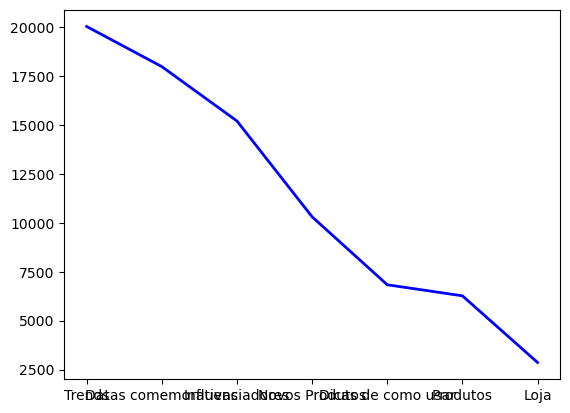

In [94]:
# Fazendo plot para tags

# Adicionando novos dados nesse grafico
# Verificando se o grafico não teve interferencia de outliers



# media_mensal = baseTags.groupby("tags")["Curtidas"].mean()
# minimo = baseTags.groupby("tags")["Curtidas"].min()
# maximo = baseTags.groupby("tags")["Curtidas"].max()

# make data
groupedTags = baseTags.groupby("Tags")["Curtidas"].mean().sort_values(ascending=False)
x = groupedTags.index
y = groupedTags.values

# print (x)
# print (y)


# x = media_mensal.index.astype(str)
# y = media_mensal.values
# x1 = minimo.index.astype(str)
# y1 = minimo.values
# x2 = maximo.index.astype(str)
# y2 = maximo.values

fig, ax = plt.subplots()
ax.plot(x, y, linewidth=2, c='b')
# ax.plot(x1, y1, linewidth=2, c='r')
# ax.plot(x2, y2, linewidth=2, c='g')


plt.show()

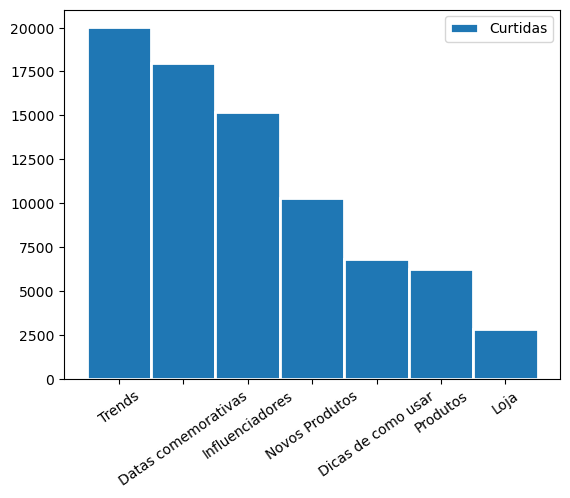

In [121]:
# Ajustando o eixo X

# Fazendo plot de barras para tags

# make data
groupedTags = baseTags.groupby("Tags")["Curtidas"].mean().sort_values(ascending=False)
x = groupedTags.index
y = groupedTags.values

fig, ax = plt.subplots()
ax.bar(x, y, width=1, edgecolor='w', linewidth=2, label='Curtidas')
ax.tick_params('x', labelrotation=35)
ax.legend()

plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


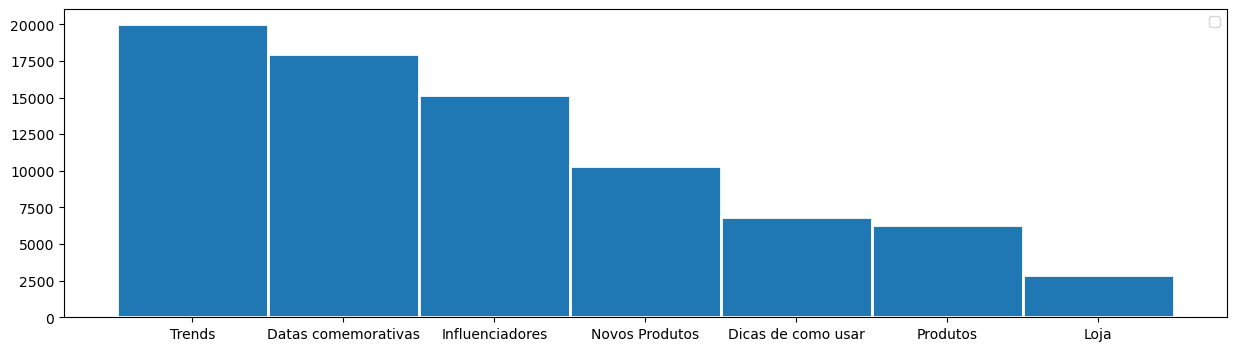

In [115]:
# Ajustando o eixo X

# Fazendo plot de barras para tags

# make data
groupedTags = baseTags.groupby("Tags")["Curtidas"].mean().sort_values(ascending=False)
x = groupedTags.index
y = groupedTags.values

fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(x, y, width=1, edgecolor='w', linewidth=2)
ax.legend()

plt.show()


In [ ]:
# Inserindo as quantidades de curtidas nos gráficos
## Para isso, vamos usar o annotate
## https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html
## Com ele você consegue colocar qualquer texto no seu gráfico
## Basta usar: plt.annotate("Texto", (x,y))
## Precisamnos passar de argumentos
## Texto que vai ser escrito
## Posição (x, y) onde texto vai estar

In [140]:
y

array([20024.        , 17975.        , 15197.28571429, 10304.88888889,
        6833.4       ,  6269.82352941,  2865.        ])

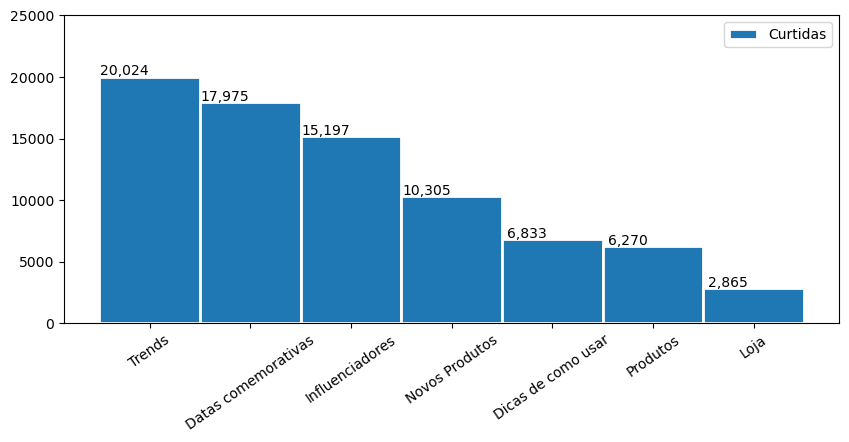

In [188]:
## Melhorando a visualização do grafico

# make data
groupedTags = baseTags.groupby("Tags")["Curtidas"].mean().sort_values(ascending=False)
x = groupedTags.index
y = groupedTags.values

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x, y, width=1, edgecolor='w', linewidth=2, label="Curtidas")
ax.legend()

ax.tick_params('x', labelrotation=35)
# plt.annotate(y[0],(x[0] , y[0]))
# plt.annotate(y[1],(x[1] , y[1]))
# plt.annotate(y[2],(x[2] , y[2]))

# for i in range(len(y)):
#     plt.annotate(y[i],(i-0.25 , y[i]))

for i in range(len(y)):
    plt.annotate(
        '{:,.0f}'.format(y[i]), # Formatando numeros
        (i-0.25 , y[i]), # Colocando posição 
        # Outros parametros
        ha='center', # Alinhamento horizontal
        xytext=(0,1), # deslocamento x,y do texto
        textcoords="offset points" # Referencial que camos fazer para o deslocamento
        )

ax.set(ylim=(0, y[0] + 5000))
plt.show()